In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import uproot
import awkward as ak
import tabulate as tab
import glob
import h5py
from tqdm import tqdm

from scipy.signal import find_peaks


# Find peaks

In [ ]:
## algo
def estimate_baseline_drift(record, chunk=2000, q=10):
    """
    Baseline proxy per chunk: q-th percentile (q=10 works well when pulses are positive-going).
    Returns:
      baseline_chunks: array of per-chunk baseline estimates
      drift_ptp: peak-to-peak baseline variation across record
      drift_std: std of baseline across chunks
    """
    n = len(record)
    baselines = []
    for start in range(0, n, chunk):
        seg = record[start:start + chunk]
        baselines.append(np.percentile(seg, q))
    baselines = np.asarray(baselines, dtype=np.float64)
    return baselines, float(np.ptp(baselines)), float(np.std(baselines))

def constant_fraction_crossing_index(y, peak_idx, frac=0.2, search_back=400):
    """
    Find rising-edge crossing time at `frac` of peak height, for one detected peak.

    Args:
      y: baseline-subtracted waveform (1D)
      peak_idx: index of peak maximum (from find_peaks)
      frac: fraction of peak height (e.g. 0.1, 0.2, 0.3)
      search_back: how far left of peak to search for the rising edge

    Returns:
      align_idx: integer index of threshold crossing on rising edge
                (nearest sample at or just after crossing).
                Returns None if not found.
    """
    peak_val = y[peak_idx]
    if peak_val <= 0:
        return None

    thr = frac * peak_val
    start = max(0, peak_idx - search_back)

    seg = y[start:peak_idx + 1]  # include peak sample
    # Find first index where seg goes from below thr to >= thr
    above = seg >= thr
    if not np.any(above):
        return None

    k = np.argmax(above)  # first True
    align_idx = start + k
    return int(align_idx)

def extract_peaks_from_records(
    X,
    *,
    # Peak detection (baseline-subtracted, in ADC counts)
    height=80.0,
    prominence=150.0,
    distance=150,

    # Baseline estimation for peak finding
    baseline_chunk=2000,
    baseline_q=10,

    # Drift flagging threshold (ADC counts)
    drift_ptp_threshold=200.0,

    # Constant-fraction alignment parameters
    align_frac=0.2,          # 20% is a common sweet spot
    align_search_back=400,   # how far before argmax to look
):
    """
    Args:
      X: array (N_records, N_samples)
    Returns:
      results: list of dicts, one per record with:
        - peaks_idx: (N_peaks,) indices in original trigger record
        - peaks_height: (N_peaks,) baseline-subtracted peak heights
        - baseline_trace: (N_samples,) piecewise-linear baseline estimate (qth percentile per chunk)
        - baseline_chunks: (N_chunks,) raw chunk baselines
        - drift_ptp, drift_std
        - flagged_drift: bool

        - align_idx: constant-fraction rising-edge crossing indices
    """
    results = []
    n_records, n_samples = X.shape

    for r in range(n_records):
        rec = X[r].astype(np.float64, copy=False)

        # Chunk baseline estimates (robust to pulses if q is low)
        baseline_chunks, drift_ptp, drift_std = estimate_baseline_drift(
            rec, chunk=baseline_chunk, q=baseline_q
        )

        # Build a baseline trace by interpolating chunk baselines to all samples
        centers = np.arange(len(baseline_chunks)) * baseline_chunk + (baseline_chunk - 1) / 2
        centers = np.clip(centers, 0, n_samples - 1)
        idx = np.arange(n_samples)
        baseline_trace = np.interp(idx, centers, baseline_chunks)

        # Baseline-subtracted waveform for peak finding
        y = rec - baseline_trace

        # Peak detection
        peaks_idx, props = find_peaks(
            y,
            height=height,
            prominence=prominence,
            distance=distance,
        )

        peaks_height = props["peak_heights"]  # same length as peaks_idx

        # Compute constant-fraction alignment indices
        align_idx = np.full_like(peaks_idx, fill_value=-1, dtype=np.int32)
        for i, p in enumerate(peaks_idx):
            a = constant_fraction_crossing_index(
                y, int(p),
                frac=align_frac,
                search_back=align_search_back
            )
            align_idx[i] = -1 if a is None else a

        # You may want to drop peaks where alignment failed
        ok = align_idx >= 0

        results.append({
            "record_index": r,

            "peaks_idx": peaks_idx.astype(np.int32), # peak position
            "peaks_height": peaks_height.astype(np.float32),
            "peaks_prominence": props["prominences"].astype(np.float32),

            # constant-fraction crossing
            "align_idx": align_idx.astype(np.int32),  # alignment     
            "align_frac": float(align_frac),

            "baseline_chunks": baseline_chunks.astype(np.float32),
            "baseline_trace": baseline_trace.astype(np.float32),
            "drift_ptp": drift_ptp,
            "drift_std": drift_std,
            "flagged_drift": bool(drift_ptp > drift_ptp_threshold),

            # convenience counts
            "n_peaks": int(len(peaks_idx)),
            "n_aligned": int(np.sum(ok)),
        })

    return results

In [7]:
## plots

def plot_record_qc_from_result(
    X,
    result: dict,
    *,
    pre: int = 40,
    post: int = 216,
    max_pulses_to_plot: int | None = 200,
    show_baseline_overlay: bool = True,
):
    """
    QC plot driven by a single 'result' dict (one record entry from `results`).
    Uses:
      - result["record_index"]
      - result["baseline_trace"]
      - result["peaks_idx"]
      - drift stats + flagged status

    Returns:
      windows: (N_valid_peaks, pre+post) baseline-subtracted windows
      valid_peaks: indices in original record of peaks actually windowed (not near edges)
    """
    i = int(result["record_index"])
    rec = X[i].astype(np.float64, copy=False)

    baseline = np.asarray(result["baseline_trace"], dtype=np.float64)
    # peaks = np.asarray(result["peaks_idx"], dtype=np.int64)
    peaks = np.asarray(result["align_idx"], dtype=np.int64)

    # Baseline-subtracted waveform
    y = rec - baseline

    # Extract windows around peaks
    win_len = pre + post
    windows = []
    valid_peaks = []
    for p in peaks:
        start = p - pre
        end = p + post
        if start < 0 or end > len(y):
            continue
        windows.append(y[start:end])
        valid_peaks.append(p)

    windows = np.asarray(windows, dtype=np.float64)
    valid_peaks = np.asarray(valid_peaks, dtype=np.int32)

    # Cap pulses plotted for readability
    windows_plot = windows
    if max_pulses_to_plot is not None and len(windows) > max_pulses_to_plot:
        idx = np.random.choice(len(windows), size=max_pulses_to_plot, replace=False)
        windows_plot = windows[idx]

    # ---- Plot layout ----
    fig = plt.figure(figsize=(16, 6), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax_raw = fig.add_subplot(gs[0, 0])
    ax_sub = fig.add_subplot(gs[1, 0], sharex=ax_raw)
    ax_win = fig.add_subplot(gs[:, 1])

    # A) Raw waveform (+ baseline overlay)
    ax_raw.plot(rec, linewidth=1)
    if show_baseline_overlay:
        ax_raw.plot(baseline, linewidth=1.5)
    ax_raw.set_title(
        f"Record {i}: raw waveform" + (" (baseline overlay)" if show_baseline_overlay else "")
    )
    ax_raw.set_ylabel("ADC")
    ax_raw.grid(True, alpha=0.25)

    # Info box (pulled from dict)
    drift_ptp = float(result.get("drift_ptp", np.nan))
    drift_std = float(result.get("drift_std", np.nan))
    flagged = bool(result.get("flagged_drift", False))

    info = (
        f"peaks detected: {len(peaks)}\n"
        f"peaks windowed: {len(valid_peaks)}\n"
        f"drift_ptp: {drift_ptp:.1f}\n"
        f"drift_std: {drift_std:.1f}\n"
        f"flagged: {flagged}"
    )
    ax_raw.text(
        0.01, 0.98, info,
        transform=ax_raw.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", alpha=0.85),
        fontsize=10
    )

    # B) Baseline-subtracted + peaks
    ax_sub.plot(y, linewidth=1)
    if len(valid_peaks) > 0:
        ax_sub.scatter(valid_peaks, y[valid_peaks], marker="x", s=40)
    ax_sub.set_title("Baseline-subtracted waveform with detected peaks (✕)")
    ax_sub.set_xlabel("Sample index")
    ax_sub.set_ylabel("ADC (subtracted)")
    ax_sub.grid(True, alpha=0.25)

    # C) Superimposed windows (aligned)
    if len(windows_plot) > 0:
        t = np.arange(win_len) - pre
        ax_win.plot(t, windows_plot.T, linewidth=0.8, alpha=0.35)
        ax_win.axvline(0, linestyle="--", linewidth=1)
    ax_win.set_title(f"Extracted pulse windows superimposed (n={len(windows_plot)})")
    ax_win.set_xlabel("Samples relative to peak (0 = peak)")
    ax_win.set_ylabel("ADC (subtracted)")
    ax_win.grid(True, alpha=0.25)

    plt.show()
    return windows, valid_peaks


In [39]:
# ---- Example usage ----
if __name__ == "__main__":
    path = "trig_20_chID_0.npz"
    data = np.load(path)
    X = data["X"]  # shape (20, 65600)

    results = extract_peaks_from_records(
        X,
        height=80.0,
        prominence=150.0,
        distance=150,
        baseline_chunk=2000,
        baseline_q=10,
        drift_ptp_threshold=200.0,
    )

    # Quick summary
    for r in results:
        n_peaks = len(r["peaks_idx"])
        flag = "⚠️ DRIFT" if r["flagged_drift"] else "ok"
        print(
            f"rec {r['record_index']:02d}: peaks={n_peaks:3d}  "
            f"drift_ptp={r['drift_ptp']:.1f}  ({flag})"
        )

    # # Example: access peak positions for record 0
    # print()
    # print(results[0]["peaks_idx"])

print("\nlist of entries where the alignment failed:")
for id in range(0, len(results)):
    tot = results[id]["n_peaks"]
    ali = results[id]["n_aligned"]
    if tot != ali:
        print(id, tot, ali)

rec 00: peaks= 51  drift_ptp=25.1  (ok)
rec 01: peaks= 59  drift_ptp=288.0  (⚠️ DRIFT)
rec 02: peaks= 51  drift_ptp=109.2  (ok)
rec 03: peaks= 64  drift_ptp=18.0  (ok)
rec 04: peaks= 42  drift_ptp=17.0  (ok)
rec 05: peaks= 51  drift_ptp=237.3  (⚠️ DRIFT)
rec 06: peaks= 41  drift_ptp=34.0  (ok)
rec 07: peaks= 39  drift_ptp=13.1  (ok)
rec 08: peaks= 51  drift_ptp=100.0  (ok)
rec 09: peaks= 57  drift_ptp=285.0  (⚠️ DRIFT)
rec 10: peaks= 61  drift_ptp=446.0  (⚠️ DRIFT)
rec 11: peaks= 49  drift_ptp=42.0  (ok)
rec 12: peaks= 53  drift_ptp=188.1  (ok)
rec 13: peaks= 51  drift_ptp=121.2  (ok)
rec 14: peaks= 51  drift_ptp=109.0  (ok)
rec 15: peaks= 62  drift_ptp=47.0  (ok)
rec 16: peaks= 56  drift_ptp=159.0  (ok)
rec 17: peaks= 52  drift_ptp=19.0  (ok)
rec 18: peaks= 51  drift_ptp=46.1  (ok)
rec 19: peaks= 53  drift_ptp=80.0  (ok)

list of entries where the alignment failed:


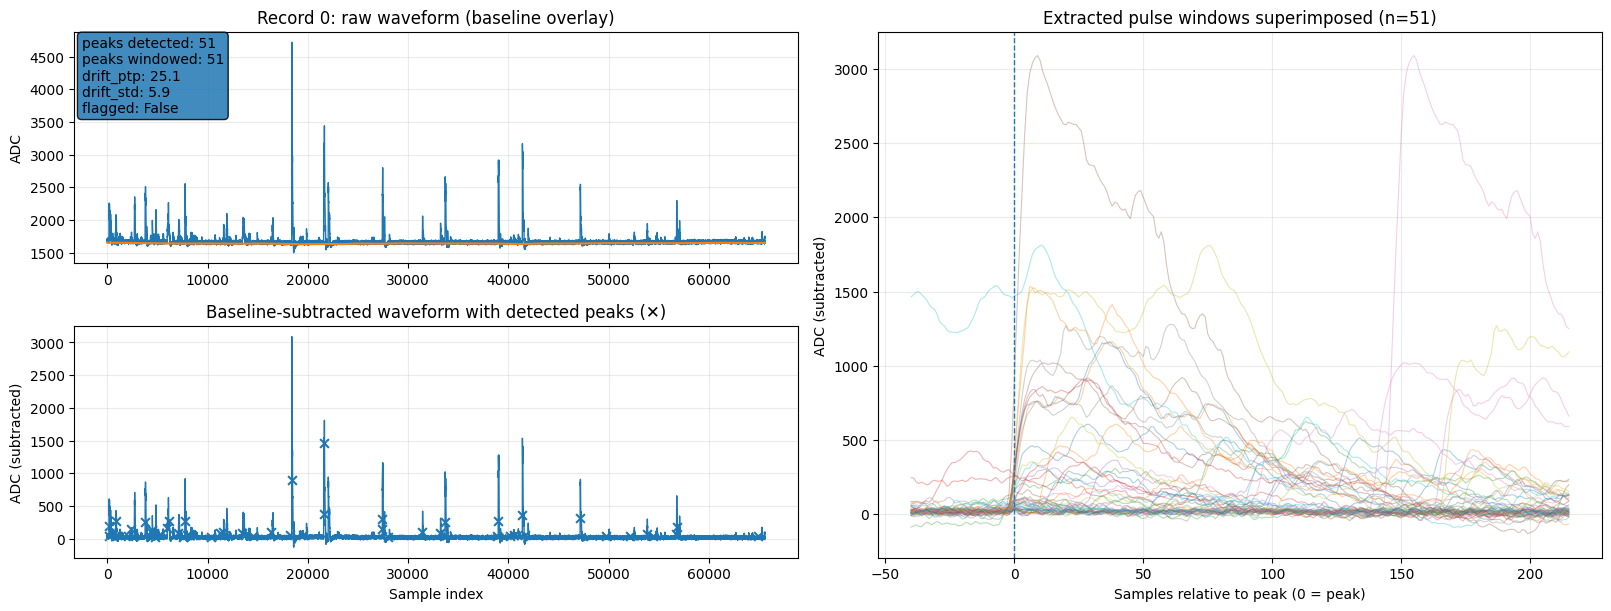

In [41]:
windows, peak_positions = plot_record_qc_from_result(
    X,
    results[0],
    pre=40,
    post=216
)

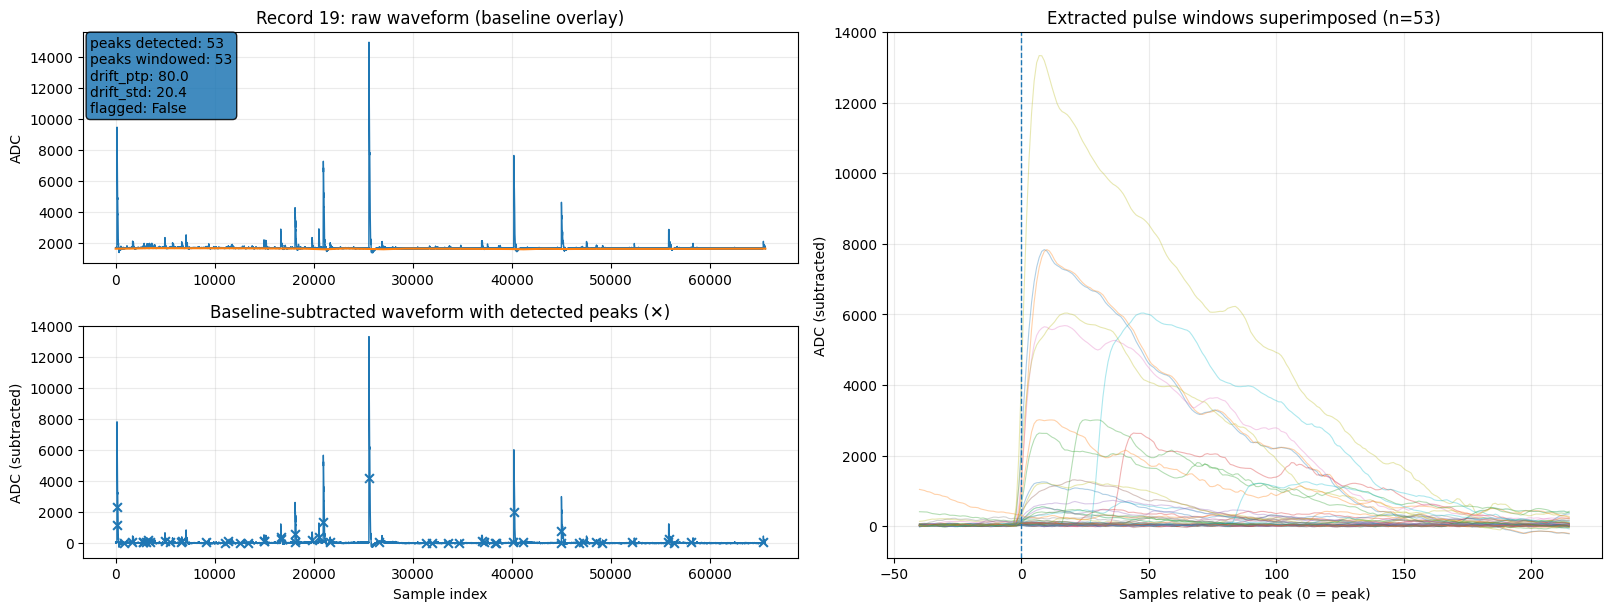

In [40]:
windows, peak_positions = plot_record_qc_from_result(
    X,
    results[19],
    pre=40,
    post=216
)

In [ ]:
windows, peak_positions = plot_record_qc_from_result(
    X,
    results[19],
    pre=40,
    post=216
)